In [1]:
# Importing libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [2]:
# Load datasets
trxn = pd.read_csv('Retail_Data_Transactions.csv')
response = pd.read_csv('Retail_Data_Response.csv')

# Merge on customer_id (left join to keep all transactions)
df = trxn.merge(response, on='customer_id', how='left')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (125000, 4)

Data Types:
 customer_id     object
trans_date      object
tran_amount      int64
response       float64
dtype: object

First 5 rows:


,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0


In [3]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Drop rows with missing values
df = df.dropna()
print("\nAfter dropping nulls:", df.shape)

# Fix data types
df['trans_date'] = pd.to_datetime(df['trans_date'], format='%d-%b-%y')
df['response'] = df['response'].astype('int64')

# Check duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

print("\nCleaned Data Types:\n", df.dtypes)
df.describe()

Missing Values:
 customer_id     0
trans_date      0
tran_amount     0
response       31
dtype: int64

After dropping nulls: (124969, 4)

Duplicate rows: 6

Cleaned Data Types:
 customer_id            object
trans_date     datetime64[ns]
tran_amount             int64
response                int64
dtype: object


,trans_date,tran_amount,response
count,124963,124963.000000,124963.000000
mean,2013-04-13 13:28:10.974128384,64.995735,0.110761
min,2011-05-16 00:00:00,10.000000,0.000000
25%,2012-04-29 00:00:00,47.000000,0.000000
50%,2013-04-15 00:00:00,65.000000,0.000000
75%,2014-03-28 00:00:00,83.000000,0.000000
max,2015-03-16 00:00:00,105.000000,1.000000
std,NaN,22.860005,0.313837


Number of outliers in tran_amount: 0
Empty DataFrame
Columns: [customer_id, trans_date, tran_amount]
Index: []


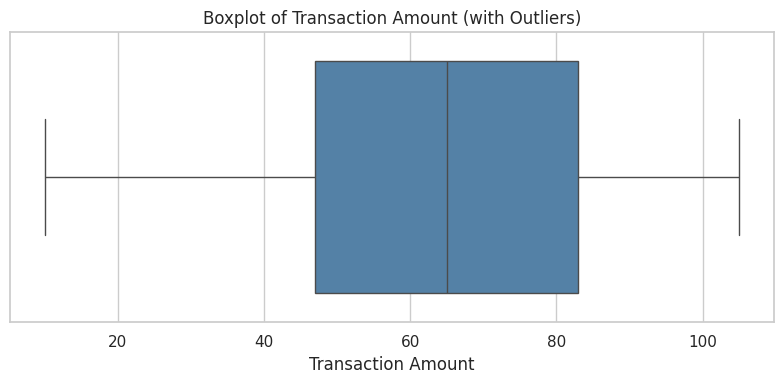


Shape after removing outliers: (124963, 4)


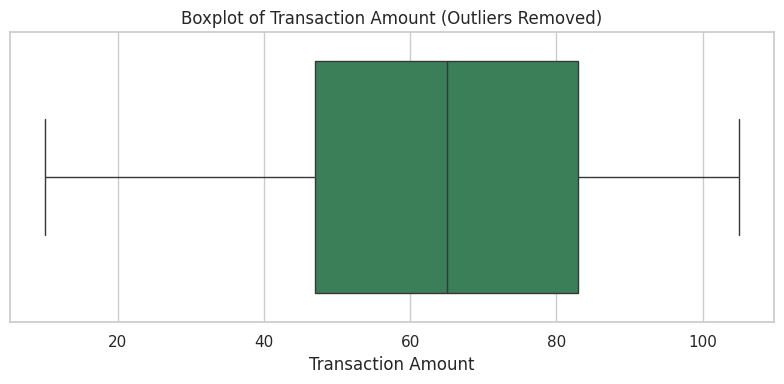

In [4]:
# Z-Score outlier detection on tran_amount
z_scores = np.abs(stats.zscore(df['tran_amount']))
threshold = 3
outliers = z_scores > threshold

print(f"Number of outliers in tran_amount: {outliers.sum()}")
print(df[outliers][['customer_id', 'trans_date', 'tran_amount']])

# Boxplot to visualize
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['tran_amount'], color='steelblue')
plt.title('Boxplot of Transaction Amount (with Outliers)')
plt.xlabel('Transaction Amount')
plt.tight_layout()
plt.show()

# Remove outliers for cleaner analysis
df = df[~outliers]
print(f"\nShape after removing outliers: {df.shape}")

# Boxplot after removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['tran_amount'], color='seagreen')
plt.title('Boxplot of Transaction Amount (Outliers Removed)')
plt.xlabel('Transaction Amount')
plt.tight_layout()
plt.show()

In [5]:
# Extract time-based features
df['month'] = df['trans_date'].dt.month
df['year'] = df['trans_date'].dt.year
df['month_year'] = df['trans_date'].dt.to_period('M')
df['day_of_week'] = df['trans_date'].dt.day_name()

print("New columns added: month, year, month_year, day_of_week")
df.head()

New columns added: month, year, month_year, day_of_week


,customer_id,trans_date,tran_amount,response,month,year,month_year,day_of_week
0,CS5295,2013-02-11,35,1,2,2013,2013-02,Monday
1,CS4768,2015-03-15,39,1,3,2015,2015-03,Sunday
2,CS2122,2013-02-26,52,0,2,2013,2013-02,Tuesday
3,CS1217,2011-11-16,99,0,11,2011,2011-11,Wednesday
4,CS1850,2013-11-20,78,0,11,2013,2013-11,Wednesday


     Month  Total Sales
0   August       726775
1  October       725010
2  January       724089


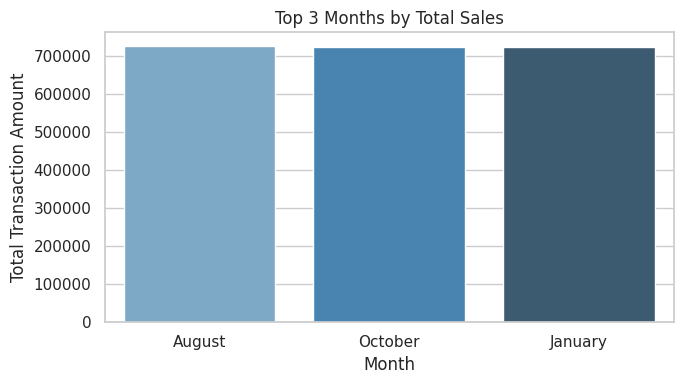

In [6]:
# Which 3 months have the highest total transaction amounts?
monthly_sales_top = df.groupby('month')['tran_amount'].sum()
monthly_sales_top = monthly_sales_top.sort_values(ascending=False).reset_index().head(3)
monthly_sales_top.columns = ['Month', 'Total Sales']
monthly_sales_top['Month'] = monthly_sales_top['Month'].apply(
    lambda x: pd.Timestamp(2000, x, 1).strftime('%B'))  # Convert number to month name

print(monthly_sales_top)

plt.figure(figsize=(7, 4))
sns.barplot(x='Month', y='Total Sales', data=monthly_sales_top, palette='Blues_d')
plt.title('Top 3 Months by Total Sales')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')
plt.tight_layout()
plt.show()

  customer_id  num_orders
0      CS4424          39
1      CS4320          38
2      CS3799          36
3      CS3805          35
4      CS3013          35


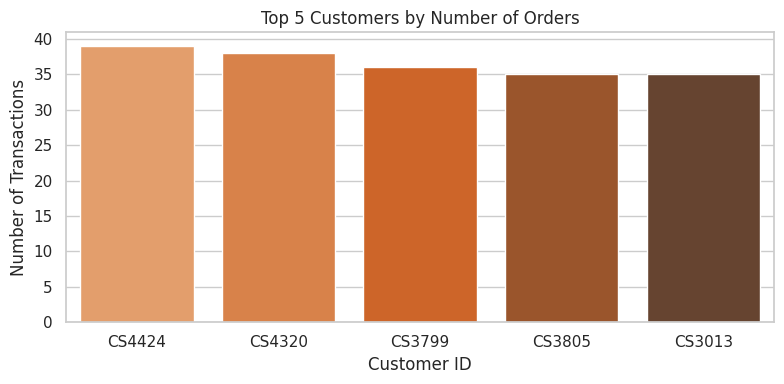

In [7]:
# Customers with the highest number of transactions
customer_counts = df['customer_id'].value_counts().reset_index().head(5)
customer_counts.columns = ['customer_id', 'num_orders']

print(customer_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x='customer_id', y='num_orders', data=customer_counts, palette='Oranges_d')
plt.title('Top 5 Customers by Number of Orders')
plt.xlabel('Customer ID')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

     customer_id  total_spend
3312      CS4424         2933
3208      CS4320         2647
4640      CS5752         2612
3548      CS4660         2527
2687      CS3799         2513


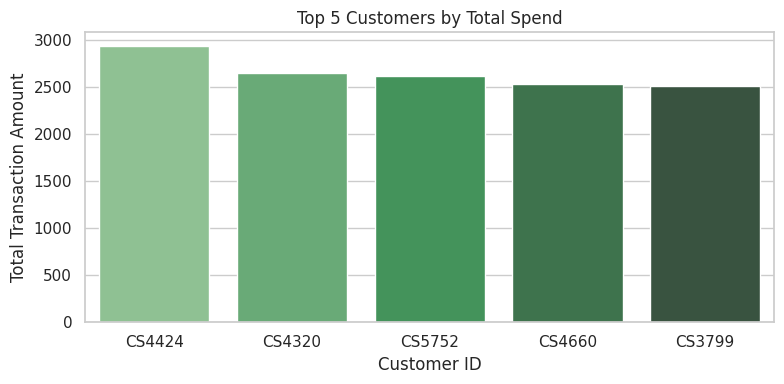

In [8]:
# Customers with the highest total spend
customer_sales = df.groupby('customer_id')['tran_amount'].sum().reset_index()
top_5_sal = customer_sales.sort_values(by='tran_amount', ascending=False).head(5)
top_5_sal.columns = ['customer_id', 'total_spend']

print(top_5_sal)

plt.figure(figsize=(8, 4))
sns.barplot(x='customer_id', y='total_spend', data=top_5_sal, palette='Greens_d')
plt.title('Top 5 Customers by Total Spend')
plt.xlabel('Customer ID')
plt.ylabel('Total Transaction Amount')
plt.tight_layout()
plt.show()

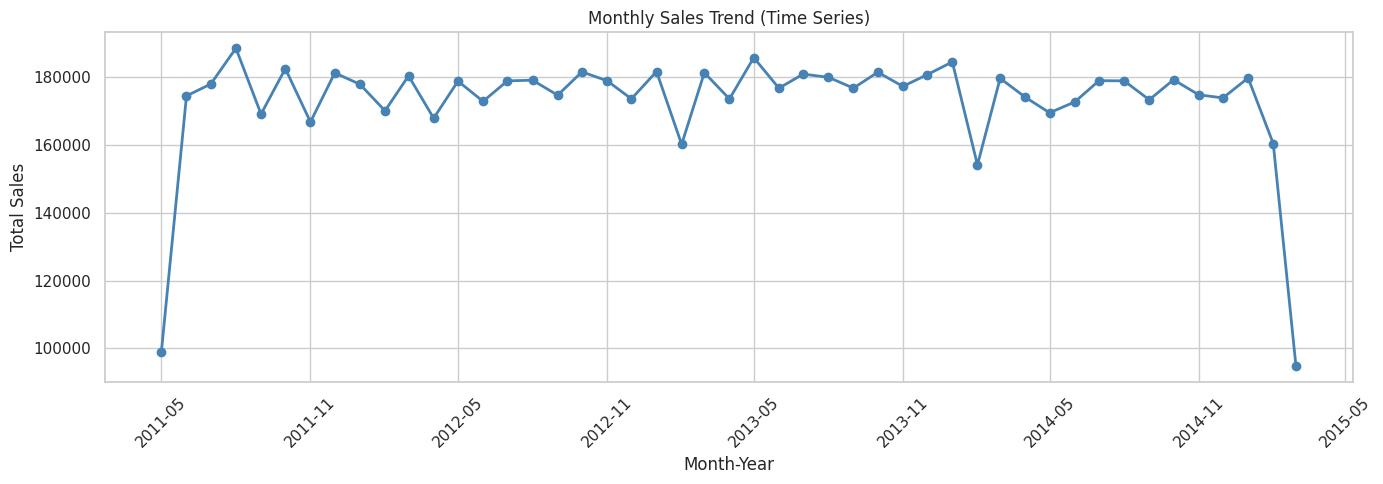

In [9]:
# Monthly sales trend over time
monthly_sales = df.groupby('month_year')['tran_amount'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='steelblue', linewidth=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend (Time Series)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Segment Distribution:
 Segment
P0 - Premium    4423
P2 - At Risk    2461
Name: count, dtype: int64


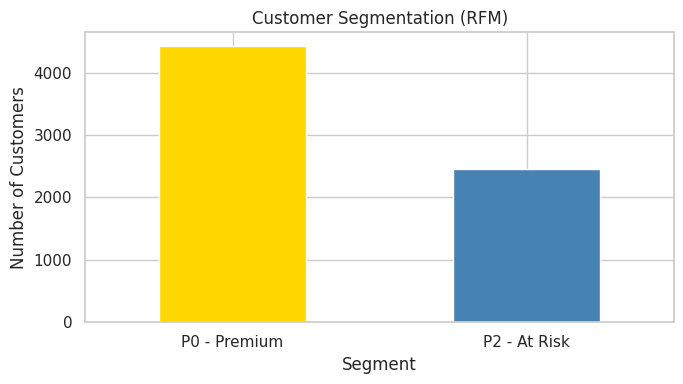

,recency,frequency,monetary,Segment
customer_id,,,,
CS1112,2015-01-14,15,1012,P0 - Premium
CS1113,2015-02-09,20,1490,P0 - Premium
CS1114,2015-02-12,19,1432,P0 - Premium
CS1115,2015-03-05,22,1659,P0 - Premium
CS1116,2014-08-25,13,857,P2 - At Risk
CS1117,2014-07-02,17,1185,P0 - Premium
CS1118,2015-03-14,15,1011,P0 - Premium
CS1119,2015-03-05,15,1158,P0 - Premium
CS1120,2015-03-06,24,1677,P0 - Premium


In [10]:
# RFM Analysis
recency = df.groupby('customer_id')['trans_date'].max()
frequency = df.groupby('customer_id')['trans_date'].count()
monetary = df.groupby('customer_id')['tran_amount'].sum()

rfm = pd.DataFrame({
    'recency': recency,
    'frequency': frequency,
    'monetary': monetary
})

# Segment customers into P0 (best), P1 (mid), P2 (others)
def segment_customer(row):
    if row['recency'].year >= 2012 and row['frequency'] >= 15 and row['monetary'] > 1000:
        return 'P0 - Premium'
    elif (2011 <= row['recency'].year < 2012) and (row['frequency'] > 10) and (row['monetary'] > 500):
        return 'P1 - Regular'
    else:
        return 'P2 - At Risk'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("Segment Distribution:\n", rfm['Segment'].value_counts())

# Plot segment distribution
plt.figure(figsize=(7, 4))
rfm['Segment'].value_counts().plot(kind='bar', color=['gold', 'steelblue', 'tomato'])
plt.title('Customer Segmentation (RFM)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

rfm.head(10)

response
No Response (Churn Risk)    111122
Responded (Active)           13841
Name: count, dtype: int64

Response Rate: 11.08%


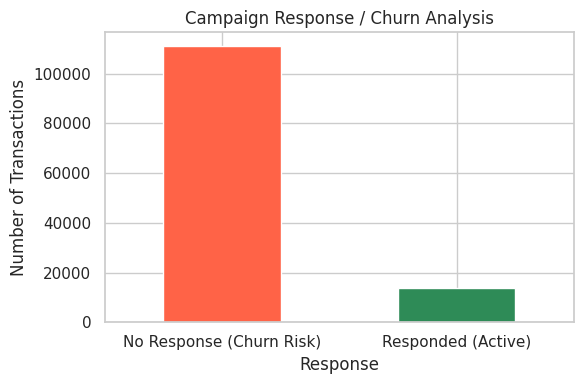

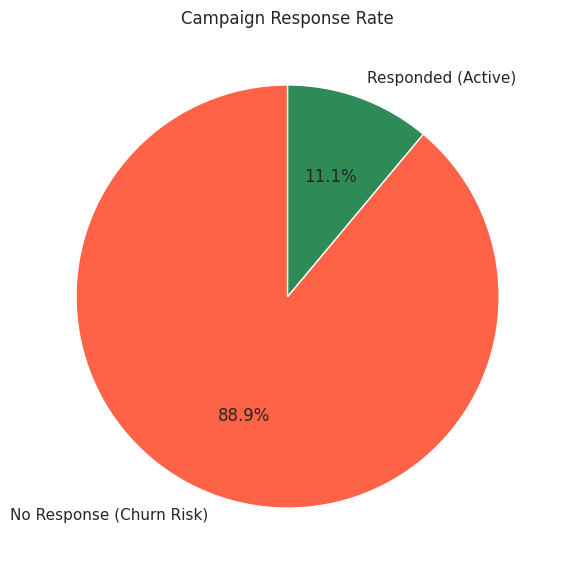

In [11]:
# Response = 1 means customer responded to campaign (active)
# Response = 0 means no response (potential churn)

churn_counts = df['response'].value_counts().rename(index={0: 'No Response (Churn Risk)', 1: 'Responded (Active)'})

print(churn_counts)
print(f"\nResponse Rate: {round(churn_counts[1] / churn_counts.sum() * 100, 2)}%")

# Bar chart
plt.figure(figsize=(6, 4))
churn_counts.plot(kind='bar', color=['tomato', 'seagreen'])
plt.title('Campaign Response / Churn Analysis')
plt.xlabel('Response')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(churn_counts.values, labels=churn_counts.index,
        autopct='%1.1f%%', colors=['tomato', 'seagreen'], startangle=90)
plt.title('Campaign Response Rate')
plt.tight_layout()
plt.show()

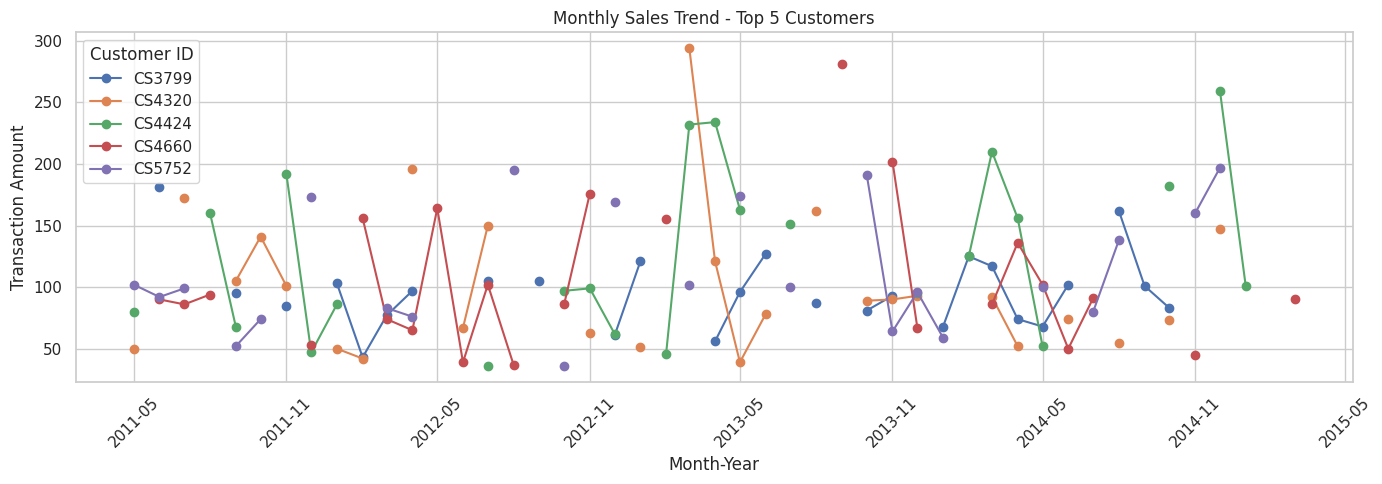

In [12]:
# Monthly sales trend for top 5 customers by spend
top_5_ids = monetary.sort_values(ascending=False).head(5).index
top_customers_df = df[df['customer_id'].isin(top_5_ids)]

top_customers_sales = top_customers_df.groupby(
    ['customer_id', 'month_year'])['tran_amount'].sum().unstack(level=0)

top_customers_sales.index = top_customers_sales.index.to_timestamp()

plt.figure(figsize=(14, 5))
for col in top_customers_sales.columns:
    plt.plot(top_customers_sales.index, top_customers_sales[col], marker='o', label=col)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel('Month-Year')
plt.ylabel('Transaction Amount')
plt.title('Monthly Sales Trend - Top 5 Customers')
plt.legend(title='Customer ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

   Year  Total Sales  Growth %
0  2011      1339965       NaN
1  2012      2115475     57.88
2  2013      2137124      1.02
3  2014      2094363     -2.00
4  2015       435135    -79.22


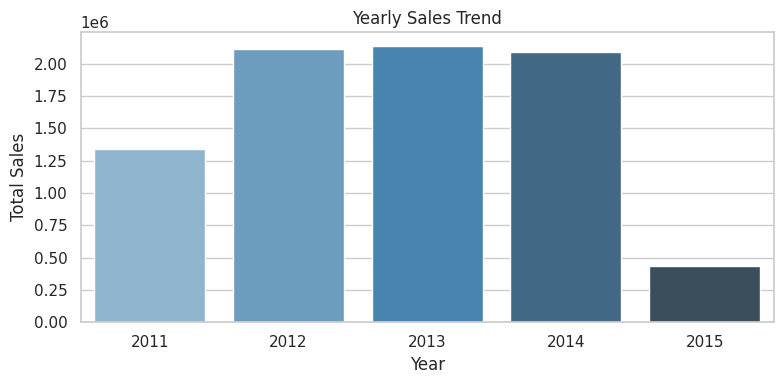

In [13]:
# Sales growth year over year
yearly_sales = df.groupby('year')['tran_amount'].sum().reset_index()
yearly_sales.columns = ['Year', 'Total Sales']

# Calculate YoY growth %
yearly_sales['Growth %'] = yearly_sales['Total Sales'].pct_change() * 100
yearly_sales['Growth %'] = yearly_sales['Growth %'].round(2)

print(yearly_sales)

plt.figure(figsize=(8, 4))
sns.barplot(x='Year', y='Total Sales', data=yearly_sales, palette='Blues_d')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

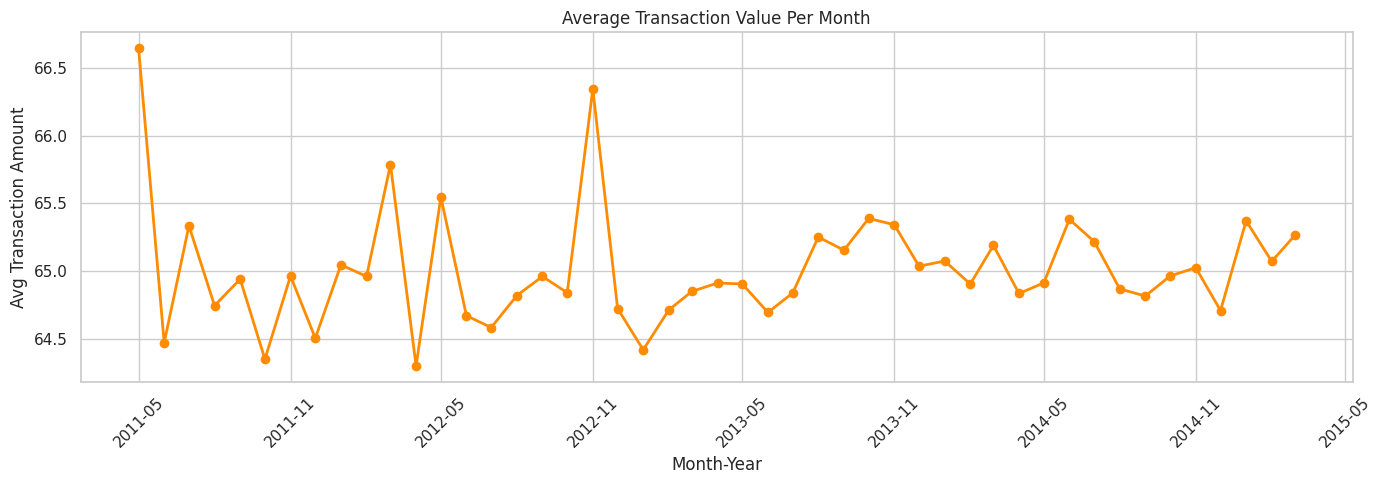

In [14]:
# Is the average spend per transaction increasing or decreasing?
avg_monthly = df.groupby('month_year')['tran_amount'].mean()
avg_monthly.index = avg_monthly.index.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(avg_monthly.index, avg_monthly.values, color='darkorange', linewidth=2, marker='o')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.title('Average Transaction Value Per Month')
plt.xlabel('Month-Year')
plt.ylabel('Avg Transaction Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

   Years Active  Number of Customers
0             2                   19
1             3                  258
2             4                 2718
3             5                 3889


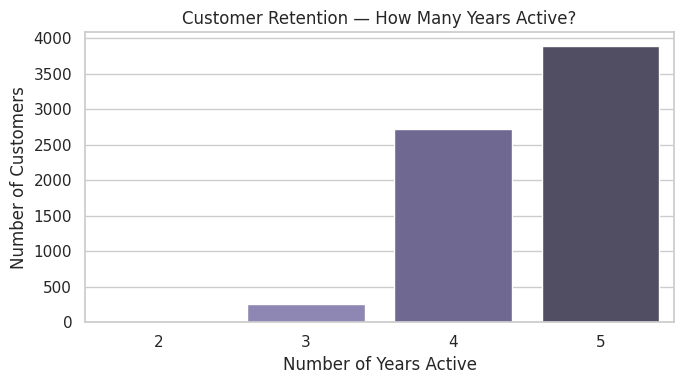

In [15]:
# How many customers came back in multiple years?
customer_years = df.groupby('customer_id')['year'].nunique().reset_index()
customer_years.columns = ['customer_id', 'years_active']

retention = customer_years['years_active'].value_counts().sort_index().reset_index()
retention.columns = ['Years Active', 'Number of Customers']

print(retention)

plt.figure(figsize=(7, 4))
sns.barplot(x='Years Active', y='Number of Customers', data=retention, palette='Purples_d')
plt.title('Customer Retention — How Many Years Active?')
plt.xlabel('Number of Years Active')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

      Response  Avg Spend  Total Spend  Num Transactions
0  No Response  64.492738      7166562            111122
1    Responded  69.034029       955500             13841


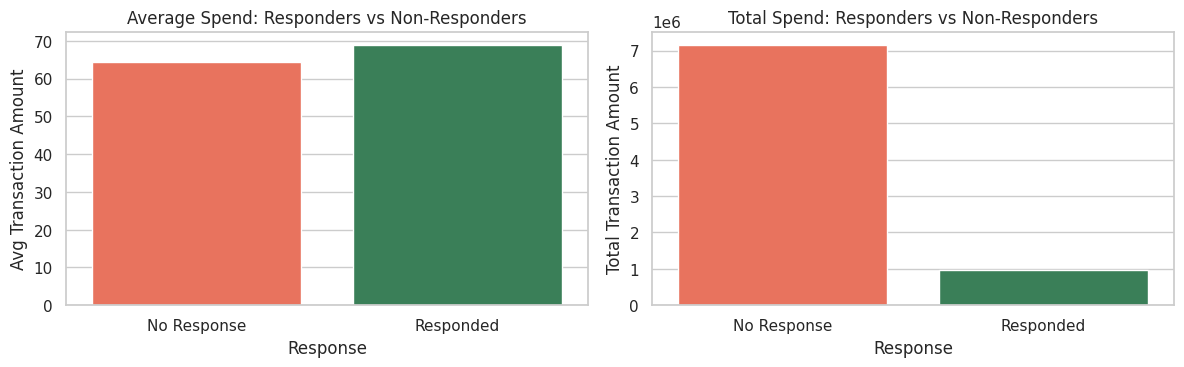

In [16]:
# Do customers who responded to campaign spend more?
spend_by_response = df.groupby('response')['tran_amount'].agg(['mean', 'sum', 'count']).reset_index()
spend_by_response.columns = ['Response', 'Avg Spend', 'Total Spend', 'Num Transactions']
spend_by_response['Response'] = spend_by_response['Response'].map({0: 'No Response', 1: 'Responded'})

print(spend_by_response)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(ax=axes[0], x='Response', y='Avg Spend', data=spend_by_response,
            palette=['tomato', 'seagreen'])
axes[0].set_title('Average Spend: Responders vs Non-Responders')
axes[0].set_ylabel('Avg Transaction Amount')

sns.barplot(ax=axes[1], x='Response', y='Total Spend', data=spend_by_response,
            palette=['tomato', 'seagreen'])
axes[1].set_title('Total Spend: Responders vs Non-Responders')
axes[1].set_ylabel('Total Transaction Amount')

plt.tight_layout()
plt.show()

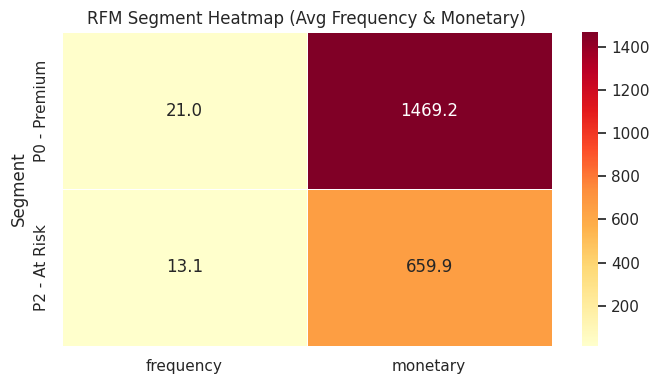

In [17]:
# Visualize RFM segments as a heatmap
rfm_summary = rfm.groupby('Segment')[['frequency', 'monetary']].mean().round(2)

plt.figure(figsize=(7, 4))
sns.heatmap(rfm_summary, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('RFM Segment Heatmap (Avg Frequency & Monetary)')
plt.tight_layout()
plt.show()

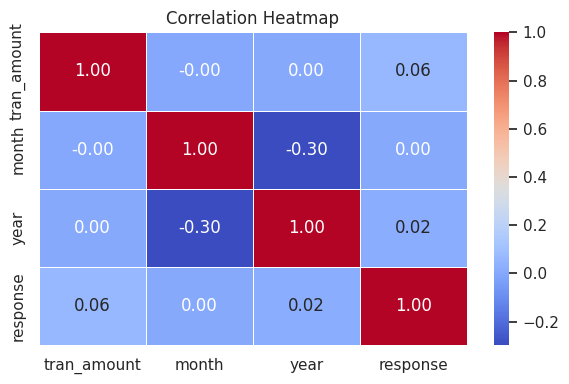

In [18]:
# Correlation between numeric columns
plt.figure(figsize=(6, 4))
numeric_cols = df[['tran_amount', 'month', 'year', 'response']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

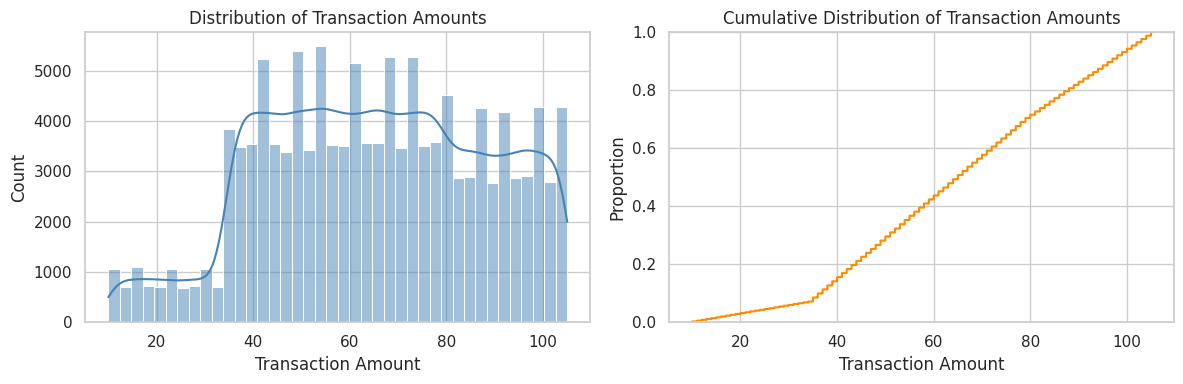

50% of transactions are below: $65.0
80% of transactions are below: $88.0


In [19]:
# How are transaction amounts distributed?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['tran_amount'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Transaction Amounts')
axes[0].set_xlabel('Transaction Amount')

sns.ecdfplot(df['tran_amount'], ax=axes[1], color='darkorange')
axes[1].set_title('Cumulative Distribution of Transaction Amounts')
axes[1].set_xlabel('Transaction Amount')

plt.tight_layout()
plt.show()

print(f"50% of transactions are below: ${df['tran_amount'].median()}")
print(f"80% of transactions are below: ${df['tran_amount'].quantile(0.8)}")

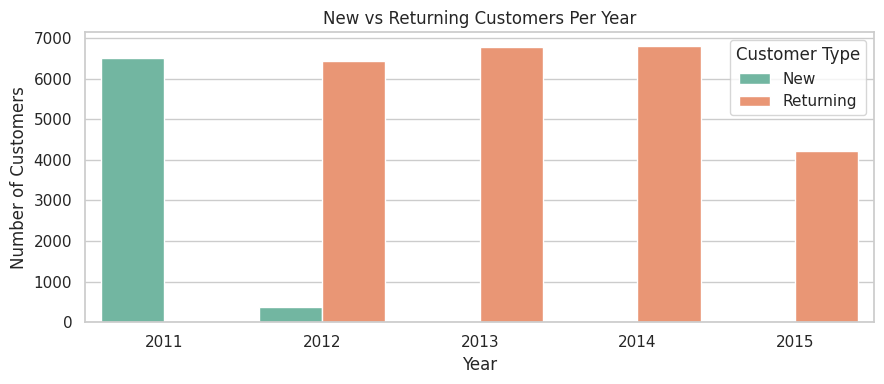

In [20]:
# First purchase year per customer
first_year = df.groupby('customer_id')['year'].min().reset_index()
first_year.columns = ['customer_id', 'first_year']

df2 = df.merge(first_year, on='customer_id')
df2['customer_type'] = df2.apply(
    lambda row: 'New' if row['year'] == row['first_year'] else 'Returning', axis=1)

cust_type_year = df2.groupby(['year', 'customer_type'])['customer_id'].nunique().reset_index()
cust_type_year.columns = ['Year', 'Customer Type', 'Count']

plt.figure(figsize=(9, 4))
sns.barplot(x='Year', y='Count', hue='Customer Type', data=cust_type_year, palette='Set2')
plt.title('New vs Returning Customers Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()